In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris

In [17]:
X , y = load_iris(return_X_y=True)
print(X[:5])
print(y[:5])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0]


In [ ]:
print(X[5:])
print(y[5:])

### Filter Data for Binary Classification

Since the current loss function is designed for binary classification, we need to filter the Iris dataset to only include two classes. We'll select classes 0 and 1 for this purpose.

In [29]:
classes_to_keep = [0, 1]
mask = np.isin(y, classes_to_keep)
X_binary = X[mask]
y_binary = y[mask]
print(f"Filtered X_binary shape: {X_binary.shape}")
print(f"Filtered y_binary shape: {y_binary.shape}")
print(y_binary[:5])

Filtered X_binary shape: (100, 4)
Filtered y_binary shape: (100,)
[0 0 0 0 0]


In [30]:
def sigmoid(s):
  return 1/(1+np.exp(-s))

In [31]:
#test :
print(sigmoid(4))

0.9820137900379085


In [32]:
def probability(X , w):
  return sigmoid(np.dot(X , w))

In [22]:
# With no weight
def loss_function(X , y, w ) :
  a = probability(X , w)
  loss = -np.mean(y*np.log(a) + (1-y)*np.log(1-a))
  return loss

In [33]:
def logistic_regression(X , y , w_initial , lr = 0.01 , epochs = 1000 ):
  w = w_initial
  loss_history = [loss_function(X , y , w)]
  for epoch in range (epochs) :
    for i in range(len(X)):
      xi = X[i]
      yi = y[i]
      ai = probability(xi , w)
      w = w - lr*(ai - yi)*xi
      loss_history.append(loss_function(xi , yi , w))
    if np.linalg.norm(w - w_initial) < 0.001:
      break
    w_initial = w
  return w , loss_history


In [ ]:
X_train , X_test , y_train , y_test = train_test_split(X_binary , y_binary , test_size=0.2 , random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)
print(X_train[:10])
print(y_train[:10])

First run without scale

In [35]:
w_final , loss_res = logistic_regression(X_train , y_train , np.zeros(X_train.shape[1]))
print(w_final)

[-0.87155742 -2.96243636  4.51000816  2.05213945]


In [36]:
print(f"Final loss : {loss_res[-1]}")

Final loss : 0.00024466897560752583


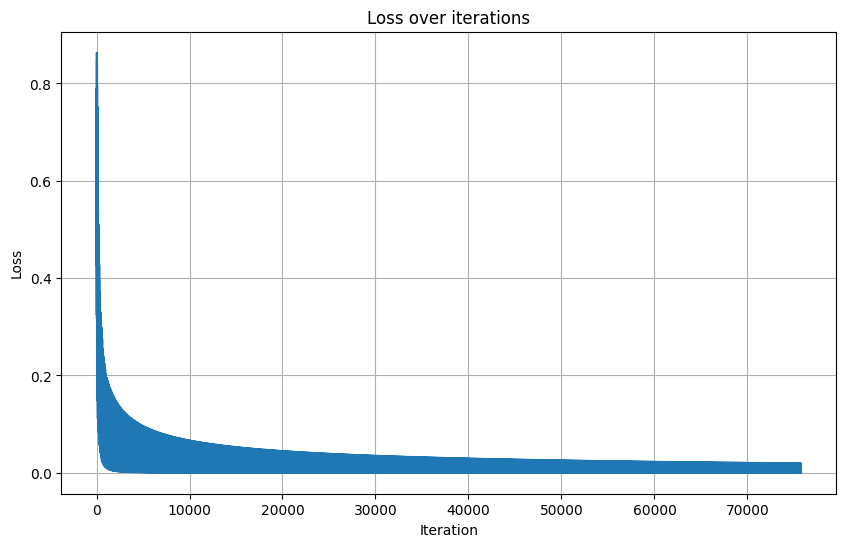

In [37]:
plt.figure(figsize=(10, 6))
plt.plot(loss_res)
plt.title('Loss over iterations')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

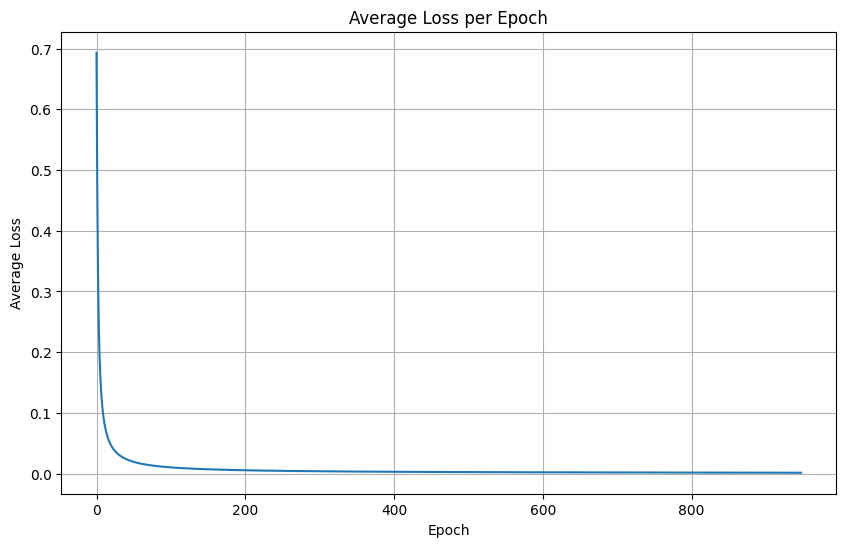

In [38]:
num_samples = len(X_train)
epoch_losses_for_plot = [loss_res[0]]
current_idx = 1
while current_idx + num_samples <= len(loss_res):
  epoch_segment = loss_res[current_idx : current_idx + num_samples]
  epoch_losses_for_plot.append(np.mean(epoch_segment))
  current_idx += num_samples
plt.figure(figsize=(10, 6))
plt.plot(epoch_losses_for_plot)
plt.title('Average Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.grid(True)
plt.show()

Scaler

In [40]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
w_scale , loss_scale = logistic_regression(X_train_scaled , y_train , np.zeros(X_train_scaled.shape[1]))
print(w_scale)
print(loss_scale[-1])

[ 1.34083572 -2.45197694  2.94242355  3.04507622]
0.0002170133096226952


With weights

In [44]:
def loss_func_weght(X , y , w , lda):
  a = probability(X , w)
  loss = -np.mean(y*np.log(a) + (1-y)*np.log(1-a))
  weight_loss = (lda/2)/X.shape[0]*np.sum(w**2)
  loss = loss + weight_loss
  return loss

In [45]:
def logistic_regression_weights(X , y , w_initial , lda , lr = 0.01 , epochs = 1000 ):
  w = w_initial
  loss_history = [loss_func_weght(X , y , w , lda)]
  for epoch in range (epochs) :
    w_before_epoch_update = np.copy(w)

    for i in range (len(X)):
      xi = X[i]
      yi = y[i]
      ai = probability(xi , w)
      gradient = (ai - yi) * xi + (lda / len(X)) * w
      w = w - lr * gradient
    current_epoch_loss = loss_func_weght(X , y , w , lda)
    loss_history.append(current_epoch_loss)
    if np.linalg.norm(w - w_before_epoch_update) < 0.001:
      break
  return w , loss_history

In [46]:
w_weight , loss_wei = logistic_regression_weights(X_train_scaled , y_train , np.zeros(X_train_scaled.shape[1]) , 0.1)
print(w_weight)
print(loss_wei[-1])

[ 1.04246075 -1.80637929  2.17712163  2.23805258]
0.013899370322096476
